# Setup 1-electrode TBtrans calculation
When using tbtrans make sure to put the environment variables (e.g. in your .bashrc): 

```bash
export OMP_NUM_THREADS=1        
export OMP_PROC_BIND=close
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sisl as si
import os
from tqdm.auto import tqdm
import time
from pathlib import Path

In [2]:
from MyTools import *
#import tbbi_periodic as  tbbi# a tight-binding model with inter-layer hopping.. 

In [3]:
from ase.visualize import view
from ase.visualize.plot import plot_atoms

In [4]:
graphene4 = si.geom.graphene(bond=1.42, orthogonal=True,vacuum=20.0)
cell4 = graphene4.cell

In [6]:
view(graphene4.to.ase())

<Popen: returncode: None args: ['/home/bastian/projects/QTM-ML/.venv/bin/pyt...>

In [7]:
Hgr4 = si.Hamiltonian(graphene4)
r = (0.1, 1.44)
t = (0.0, -2.7)
Hgr4.construct([r, t])

We will make a system of width $NW$. The device is tiled 2 times in the semi-infinite direction (since we only want a single electrode)

In [8]:
NW = 5 ## The system width

Device and electrode Hamiltonians

In [9]:
H_elec = Hgr4.copy()
H_dev = Hgr4.tile(NW,1).tile(2,0)  

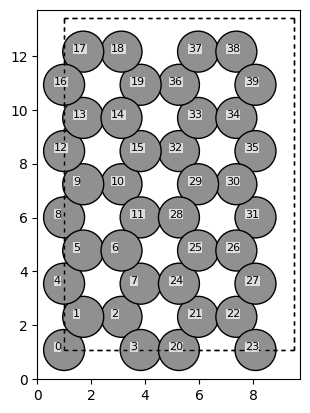

In [10]:
plot_with_numbers(H_dev)

### Initial 1-ribbon setup to create 1-ribbon $\Sigma$ with tbtrans


In [11]:
## make directory for run
tbt_dir = "./TBT_1elec-NW"+str(NW)
Path(tbt_dir).mkdir(parents=True, exist_ok=True)

In [15]:
!ls -ltr

total 132
-rwxr-xr-x 1 bastian bastian   4421 Mar 20 15:39 MyTools.py
drwxr-xr-x 2 bastian bastian   4096 Mar 26 11:47 __pycache__
-rwxr-xr-x 1 bastian bastian 115412 Mar 26 11:47 Setup-TBTrans-1-electrode-Zigzag.ipynb
drwxr-xr-x 2 bastian bastian   4096 Mar 26 11:50 TBT_1elec-NW5


In [12]:
H_dev.write(tbt_dir+"/H_dev.TSHS")
H_elec.write(tbt_dir+"/H_elec.TSHS")

In [98]:
fdfinput1=f"""SystemName siesta
SystemLabel tbt

TBT.k [1 1 1]

TBT.Elecs.Eta     0.001 eV 
TBT.Contours.Eta  0.001 eV
%block TBT.Contour.line
  from -1. eV to 1. eV  
   delta 0.01 eV
    method mid-rule
%endblock

TBT.HS ./H_dev.TSHS

TBT.CDF.SelfEnergy.Save
TBT.CDF.SelfEnergy.Save.Mean  True
TBT.T.Bulk True
TBT.DOS.Elecs True
TBT.DOS.A.All True
TBT.DOS.Gf True

%block TS.Elecs
  ELeft
%endblock TS.Elecs

%block TS.ChemPots
  x
%endblock TS.ChemPots

%block TS.ChemPot.x
  mu 0.0 eV
  contour.eq
    begin
      C-x
      T-x
    end
%endblock TS.ChemPot.x

%block TBT.Elec.ELeft
   HS ./H_elec.TSHS
   chemical-potential x
   semi-inf-direction -a1
   electrode-position 1
   bloch 1 {NW} 1
   Bulk True
%endblock TS.Elec.ELeft
"""
with open(tbt_dir+"/RUNTBT.fdf", "w") as f:
    f.write(fdfinput1)

⇨ Now run tbtrans in tbt-dir to get SEfile

In [17]:
SEfile = tbt_dir +"/tbt.TBT.SE.nc"
tbtse = si.get_sile(SEfile)
En = tbtse.E
kpts = tbtse.k
wk = tbtse.wk
eta = tbtse.eta()
a_dev = tbtse.a_dev ## Note this is the indices which the system is downfolded to in tbtrans (i.e. leaving out the original electrode)

TBtrans geometry (where the $\Sigma$ is defined):

In [18]:
g_dev0 = H_dev.geometry
tbt_atom_idx = tbtse.a_dev
g_tbtdev = g_dev0.sub(tbt_atom_idx)

### This is where you read the TBtrans SFE into a dense $\Sigma$-matrix

In [44]:
def GetSigma(e, elec=0, k=[0.,0.,0.,]):
    tmp = tbtse.self_energy(elec=0,E=e,k=k,sort=True).data
    pvt = tbtse.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)  # and downfolded to smaller region
    no_d = tbtse.no_d ## down-folded region size
    #print(tmp[0].dtype)
    ZeroMat = 0.*1j*np.eye(no_d)
    Sigma = ZeroMat.copy()  # transform to original orbit
    Sigma[pvt, pvt.T] += tmp  # transform to original orbital-index using pvt arrays.
    return Sigma

In [57]:
?tbtse.self_energy

Signature:
tbtse.self_energy(
    elec,
    E: 'float',
    k: 'Union[int, KPoint]' = 0,
    sort: 'bool' = False,
) -> 'np.ndarray'
Docstring:
Return the self-energy from the electrode `elec`

Parameters
----------
elec : str or int
   the corresponding electrode to return the self-energy from
E :
   energy to retrieve the self-energy at.
   The closest energy point will be chosen.
k :
   k-point to retrieve, if an integer it is the k-index in the file
sort :
   if ``True`` the returned self-energy will be sorted according to the order of
   the orbitals in the non-pivoted geometry, otherwise the self-energy will
   be returned according to the pivoted orbitals in the device region.
File:      ~/projects/QTM-ML/.venv/lib/python3.13/site-packages/sisl/io/tbtrans/se.py
Type:      method

warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
info:0: SislInfo: tbtsencSileTBtrans requesting energy -1.00000 eV, found -0.99500 eV as the closest energy!


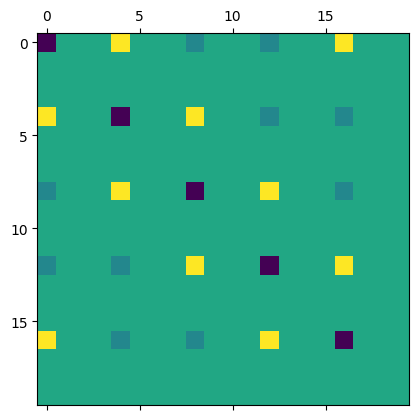

In [50]:
SFE = GetSigma(En[tbtse.Eindex(-1)])
plt.matshow(SFE.imag)

## Analysis of TBT

In [58]:
tbtout = si.io.tbtrans.tbtncSileTBtrans(tbt_dir+"/tbt.TBT.nc")
elecs = tbtout.elecs
En1 = tbtout.E

In [65]:
?tbtout.ADOS

Signature:
tbtout.ADOS(
    elec: 'ElecType' = 0,
    E: 'Optional[EType]' = None,
    kavg: 'Union[int, bool]' = True,
    atoms=None,
    orbitals=None,
    sum: 'bool' = True,
    norm: 'NormType' = 'none',
) -> 'ndarray'
Docstring:
Spectral density of states (DOS) (1/eV).

Extract the spectral DOS from electrode `elec` on a selected subset of atoms/orbitals in the device region

.. math::
   \mathrm{ADOS}_\mathfrak{el}(E) = \frac{1}{2\pi N} \sum_{i\in\{I\}} [\mathbf{G}(E)\Gamma_\mathfrak{el}\mathbf{G}^\dagger]_{ii}(E)

The normalization constant (:math:`N`) is defined in the routine `norm` and depends on the
arguments.

Parameters
----------
elec:
   electrode originating spectral function
E :
   optionally only return the DOS of atoms at a given energy point
kavg:
   whether the returned DOS is k-averaged, or an explicit (unweighed) k-point
   is returned
atoms : array_like of int or bool, optional
   only return for a given set of atoms (default to all).
   *NOT* allowed with `or

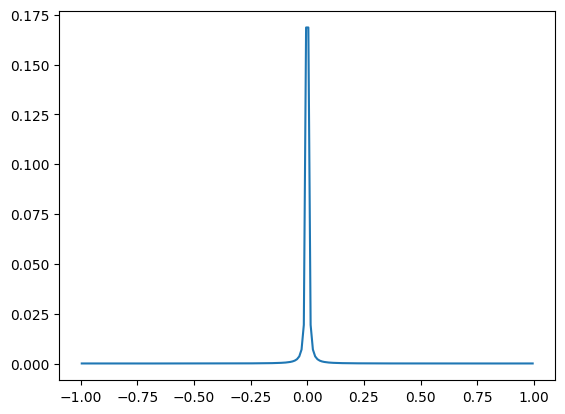

In [81]:
# Plot the ADOS on an atom
plt.plot(En1,tbtout.ADOS(atoms=tbt_atom_idx[5]))  

In [85]:
gr = si.geom.graphene(1.42).rotate([30, [0,0,1]]).tile(10,0)
gr.plot(axes='xy')

In [97]:
from ase.calculators.siesta import Siesta


gr = si.geom.graphene(1.42)


kwargs = {
    'SystemLabel':'zigzag',
}

fdf = Siesta(fdf_arguments=kwargs)

gr_ase = gr.to.ase()

gr_ase.write('testrun')


UnknownFileTypeError: Could not guess file type

Atoms(symbols='C2', pbc=[True, True, False], cell=[[2.13, -1.2297560733739028, 0.0], [2.13, 1.2297560733739028, 0.0], [0.0, 0.0, 20.0]])